In [1]:
import csv
import torch
from PIL import Image
import json
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "/project/Impressions/metadata/all_image_annotations.csv"
with open(path, "r") as f:
    reader = csv.DictReader(f)
    data = list(reader)

In [3]:
data[3]

{'AnnotatorId': 'annotator062',
 'ImgId': '0091ac4b-9315-5eaa-9044-9c6a37560b64',
 'caption': 'The Republican-led Florida Senate on Thursday passed a bill that was intended to crack down on rioting, but that critics said would criminalize the peaceful demonstrations against police brutality that have swept across the state and the country since the killing of George Floyd last year.',
 'Impact': '2.0',
 'image_description': 'There are a lot of people holding boards with words written on them, as if they are protesting. Among them, there is a lady holding a megaphone microphone, likely leading the demonstration.',
 'image_impression': "I believe this image highlights the power of collective action and the importance of standing up for one's beliefs. The caption mentioning the bill passed by the Republican-led Florida Senate adds a layer of context, indicating a potential clash between the right to protest and the efforts to curb rioting. It makes me think about the ongoing debate surrou

Check image existence

In [4]:
exist = []
image_path = "/project/Impressions/media"
for i in range(len(data)):
    raw_image = os.path.join(image_path, data[i]["ImgId"] + ".png")
    if os.path.exists(raw_image):
        exist.append(1)
    else:
        exist.append(0)

print(sum(exist), len(exist), sum(exist) / len(exist))

4278 4278 1.0


In [5]:
sorted_data = sorted(data, key=lambda x: x["ImgId"])

In [6]:
# Collect this data as json

j_data = []

# As there are items with the same ImgId, so we collect them outside of the loop
tmp_idx = 0
tmp_item = {}
for i in tqdm(range(len(data))):
    if tmp_item.get("image_id") is None:
        tmp_item["image_id"] = tmp_idx
        tmp_item["ImgId"] = data[i]["ImgId"]
        tmp_item["image"] = data[i]["ImgId"] + ".png"
        tmp_item["caption"] = []
    else:
        if tmp_item["ImgId"] != data[i]["ImgId"]:
            tmp_idx += 1
            # tmp_item["caption"] = list(set(tmp_item["caption"]))
            j_data.append(tmp_item)
            tmp_item = {}
            tmp_item["image_id"] = tmp_idx
            tmp_item["ImgId"] = data[i]["ImgId"]
            tmp_item["image"] = data[i]["ImgId"] + ".png"
            tmp_item["caption"] = []
    caption_collection = []
    caption_collection.append(data[i]["caption"])
    caption_collection.append(data[i]["image_description"])
    caption_collection.append(data[i]["image_impression"])
    caption_collection.append(data[i]["image_aesthetic_eval"])
    tmp_item["caption"] += caption_collection

100%|██████████| 4278/4278 [00:00<00:00, 878837.86it/s]


In [7]:
j_data[5]

{'image_id': 5,
 'ImgId': 'd3296721-d2de-52ce-b317-72f2865880c9_cap1_0',
 'image': 'd3296721-d2de-52ce-b317-72f2865880c9_cap1_0.png',
 'caption': ['even Mister Rogers',
  "It's a black and white photo of a smiling Fred Rogers, also known as Mr. Rogers. He's wearing a sweater and a tie.",
  'It makes me think that he seems like a very sympathetic person, judging by his smile. It also made me think how he is such an iconic figure.',
  "The black and white colors immortalizes Mr. Rogers' look and face. It also eliminates any distraction from the photo, giving us the essence of his smile.",
  'even Mister Rogers',
  "This image shows the iconic Fred Rogers from the show Mister Rogers' Neighborhood. He is wearing his trademark cardigan sweater with a dress shirt and tie. He is smiling at the camera in this promotional photograph.",
  'This image instantly makes me feel happy as I imagine my hours as a child watching his show. His show represented a simpler, more trusting time and I wish we 

In [8]:
num_captions_count = []
for i in range(len(j_data)):
    num_captions_count.append(len(j_data[i]["caption"]))
print(
    sum(num_captions_count),
    len(num_captions_count),
    sum(num_captions_count) / len(num_captions_count),
    min(num_captions_count),
    max(num_captions_count),
    np.median(num_captions_count),
)

17100 2125 8.047058823529412 4 40 8.0


In [9]:
# count how many numers are there in the num_captions_count
print(num_captions_count.count(4))
print(num_captions_count.count(8))
print(num_captions_count.count(12))
print(num_captions_count.count(16))
print(num_captions_count.count(20))
print(num_captions_count.count(24))
print(num_captions_count.count(28))
print(num_captions_count.count(32))
print(num_captions_count.count(36))
print(num_captions_count.count(40))

706
728
672
7
8
2
1
0
0
1


students graduating at the University of South Carolina
A girl posing for the camera with her graduating gown. She is holding a file that displays her school name. There are also people standing in the background, and someone is taking a picture of the girl. This image represents a moment of celebration and achievement as students graduate from the University of South Carolina. It evokes a sense of pride and accomplishment for the girl in the picture and her peers.
I feel a sense of joy and excitement for their academic success. It also reminds me of the significance of graduation ceremonies and the hard work that goes into earning a degree.
The girl's pose and her proud expression convey a sense of accomplishment. The file adds a personal touch and signifies her affiliation with the University of South Carolina. The presence of other people and someone capturing the moment with a camera suggests a shared experience of graduation.
students graduating at the University of South Carolina

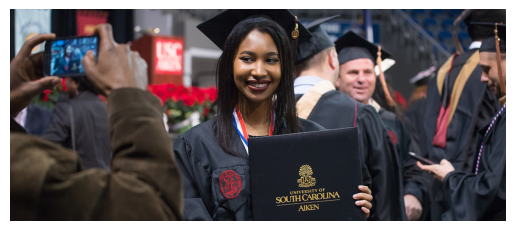

In [10]:
idx = 14
image = os.path.join(image_path, j_data[idx]["image"])
image = Image.open(image).convert("RGB")
plt.imshow(image)
plt.axis("off")

print(*j_data[idx]["caption"], sep="\n")

In [11]:
json.dump(j_data, open("/project/Impressions/metadata/impressions.json", "w"), indent=4)

In [12]:
# Collect this data as json

j_data = []

# As there are items with the same ImgId, so we collect them outside of the loop
for i in tqdm(range(len(data))):
    tmp_item = {}
    tmp_item["image_id"] = i
    tmp_item["ImgId"] = data[i]["ImgId"]
    tmp_item["image"] = data[i]["ImgId"] + ".png"
    caption_collection = []
    caption_collection.append(data[i]["caption"])
    caption_collection.append(data[i]["image_description"])
    caption_collection.append(data[i]["image_impression"])
    caption_collection.append(data[i]["image_aesthetic_eval"])
    tmp_item["caption"] = caption_collection
    j_data.append(tmp_item)


100%|██████████| 4278/4278 [00:00<00:00, 643218.83it/s]


In [13]:
j_data[1]

{'image_id': 1,
 'ImgId': '00715db9-9c9e-5d82-a41e-1e23b3a23659_cap2_2',
 'image': '00715db9-9c9e-5d82-a41e-1e23b3a23659_cap2_2.png',
 'caption': ['California',
  'In the background the skyscrapers rise up, rich professionals, while in front it is possible to notice lower buildings, not uniform and modest, but brightly colored',
  'The presence of a diverse range of buildings, makes me think of a city full of diversity, culture and disparity',
  'The contrast between the background (tall and rich skyscrapers) and the foreground (lower and poorer buildings) seems to be a metaphor for the demographic composition of the city']}

Joe Spallina had just delivered his speech and handed out his pregame assignments, but before his Stony Brook womens lacrosse team left the locker room to play fourth-ranked Syracuse at the Carrier Dome last year, the brash head coach paused.
A group of young girls wearing white shirts and red shorts uniforms are standing on a field. They are holding up a long item, which could be a lacrosse stick, as they prepare to play the sport.
This image evokes a sense of youth, teamwork, and sportsmanship. It may make me think about the importance of coaching and mentorship in youth sports and the dedication of young athletes. It could also inspire thoughts about the power of sports in bringing people together and fostering a sense of camaraderie.
The presence of the young girls in their uniforms and holding up the lacrosse sticks symbolizes their participation and engagement in the sport. The field where they are standing signifies the arena for their athletic endeavors. The colors of their uni

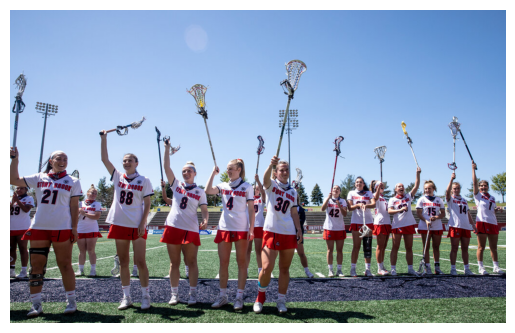

In [14]:
idx = 1080
image = os.path.join(image_path, j_data[idx]["image"])
image = Image.open(image).convert("RGB")
plt.imshow(image)
plt.axis("off")

print(*j_data[idx]["caption"], sep="\n")

In [15]:
json.dump(j_data, open("/project/Impressions/metadata/impressions_single.json", "w"), indent=4)